In [126]:
import pandas as pd
import joblib
import numpy as np  
import matplotlib.pyplot as plt
import os.path as osp

from matplotlib.colors import LogNorm, LinearSegmentedColormap
import matplotlib.ticker as ticker

from scipy.interpolate import griddata


In [2]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_go1_jump/results"

In [3]:
colors = [
    (0, "#25540d"),  # Strong green
    (0.5, "#7ef542"), #Light green
    (0.75, "#fff838"),  # Yellow
    (1, "#ff3838")     # Red
]
cmap = LinearSegmentedColormap.from_list("green_yellow_red", colors)


# Complete policy

### No heihgt, only liner part

In [4]:
exp_path = osp.join(data_path, 'complete_linear_no_height')

In [5]:
data_pos = osp.join(exp_path, "pos_err.bin")
data_orient_err = osp.join(exp_path, "orient_err.bin")
data_fail = osp.join(exp_path, "failed.bin")

In [6]:
pos = joblib.load(data_pos)
orient_err = joblib.load(data_orient_err)
fail = joblib.load(data_fail)

In [7]:
des_pos = pos[0][:,:2]

In [8]:
actual_pos = pos[1][:,:2]

In [9]:
pos_err = np.linalg.norm(des_pos - actual_pos, axis=1)

In [10]:
print("avg pos error: ", pos_err.mean())

avg pos error:  0.13864443


In [11]:
failed_idx = np.nonzero(fail)[0]
print("failed jumps: ", failed_idx.shape)

failed jumps:  (0,)


In [12]:
failed_jump_des = des_pos[failed_idx]

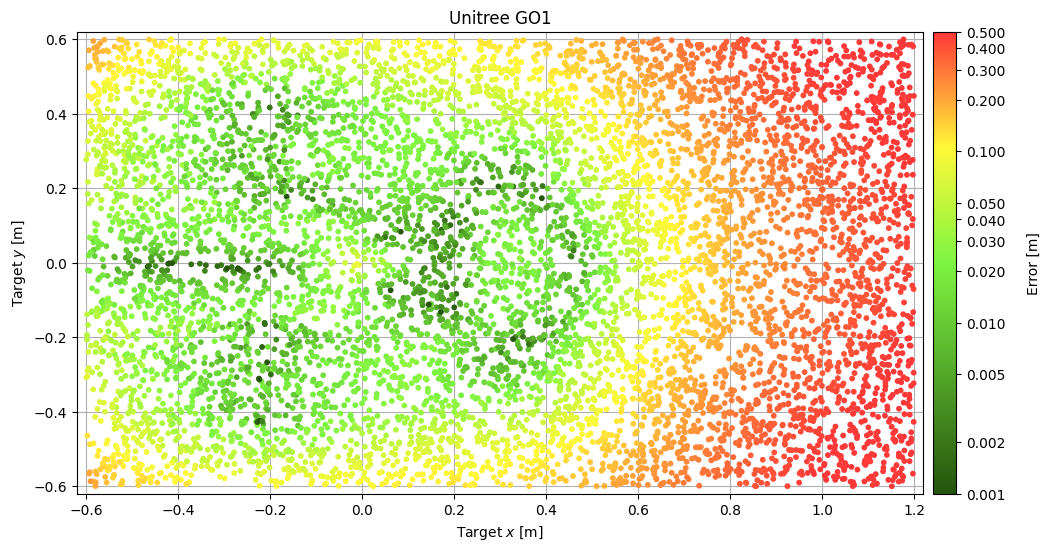

In [13]:
plt.figure(figsize=(13, 6))

plt.grid()

# Enlarge marker size for failed jumps
plt.scatter(failed_jump_des[:, 0], failed_jump_des[:, 1], 
            np.full(failed_jump_des[:, 1].shape, 100),  # Enlarged marker size
            marker='o', color="red", zorder=1)

# Enlarge marker size for desired positions with custom log scale for error values
sc = plt.scatter(des_pos[:, 0], des_pos[:, 1], 
                 np.full(des_pos[:, 1].shape, 10),  # Enlarged marker size
                 marker='o', c=pos_err, zorder=10, 
                 norm=LogNorm(vmin=1e-3, vmax=0.5), cmap=cmap)  # Apply the custom colormap

plt.xlim(-0.62, 1.22)
plt.ylim(-0.62, 0.62)

# Set x-axis ticks with equal spacing of 0.1
plt.xticks(np.arange(-0.6, 1.3, 0.2))  # Generate ticks from -0.6 to 1.2 with a step of 0.1

# Add colorbar with specified ticks and labels, adjust 'pad' to bring it closer to the plot
cbar = plt.colorbar(sc, pad=0.01)  # Reduce the pad value to bring the colorbar closer
cbar.set_ticks([1e-3, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5])  # Custom tick locations
cbar.ax.yaxis.set_major_formatter(ticker.ScalarFormatter())  # Display values in scalar form
cbar.ax.minorticks_off()

# Add label to colorbar with label padding
cbar.set_label("Error [m]", labelpad=15)  # Adjust label padding

# Add grid, title, and labels
plt.title("Unitree GO1")
plt.xlabel("Target $x$ [m]")
plt.ylabel("Target $y$ [m]")

# Automatically adjust layout
# plt.tight_layout()

# Save and show plot
plt.savefig(osp.join(data_path , "abs_err.pdf"), dpi=500, bbox_inches='tight')
plt.show()

In [14]:
feasible_idx = pos_err <= 0.2

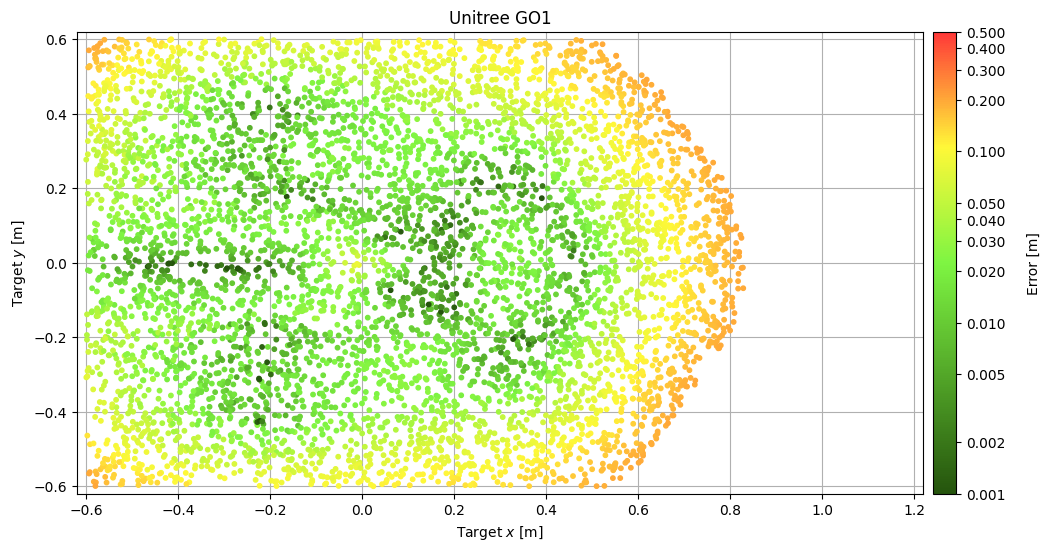

In [15]:
plt.figure(figsize=(13, 6))

plt.grid()

# Enlarge marker size for desired positions with custom log scale for error values
sc = plt.scatter(des_pos[:, 0][feasible_idx], des_pos[:, 1][feasible_idx], 
                 np.full(des_pos[:, 1][feasible_idx].shape, 10),  # Enlarged marker size
                 marker='o', c=pos_err[feasible_idx], zorder=10, 
                 norm=LogNorm(vmin=1e-3, vmax=0.5), cmap=cmap)  # Apply the custom colormap

plt.xlim(-0.62, 1.22)
plt.ylim(-0.62, 0.62)

# Set x-axis ticks with equal spacing of 0.1
plt.xticks(np.arange(-0.6, 1.3, 0.2))  # Generate ticks from -0.6 to 1.2 with a step of 0.1

# Add colorbar with specified ticks and labels, adjust 'pad' to bring it closer to the plot
cbar = plt.colorbar(sc, pad=0.01)  # Reduce the pad value to bring the colorbar closer
cbar.set_ticks([1e-3, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5])  # Custom tick locations
cbar.ax.yaxis.set_major_formatter(ticker.ScalarFormatter())  # Display values in scalar form
cbar.ax.minorticks_off()

# Add label to colorbar with label padding
cbar.set_label("Error [m]", labelpad=15)  # Adjust label padding

# Add grid, title, and labels
plt.title("Unitree GO1")
plt.xlabel("Target $x$ [m]")
plt.ylabel("Target $y$ [m]")

# Automatically adjust layout
# plt.tight_layout()

# Save and show plot
plt.savefig(osp.join(data_path , "abs_err_feasible.pdf"), dpi=500, bbox_inches='tight')
plt.show()

In [16]:
des_dist = np.linalg.norm(des_pos, axis=1)

In [17]:
actual_dist = np.linalg.norm(actual_pos, axis=1)

In [18]:
front_jumps = des_pos[:, 0] >= 0  # Front jumps if x >= 0
back_jumps = des_pos[:, 0] < 0    # Back jumps if x < 0

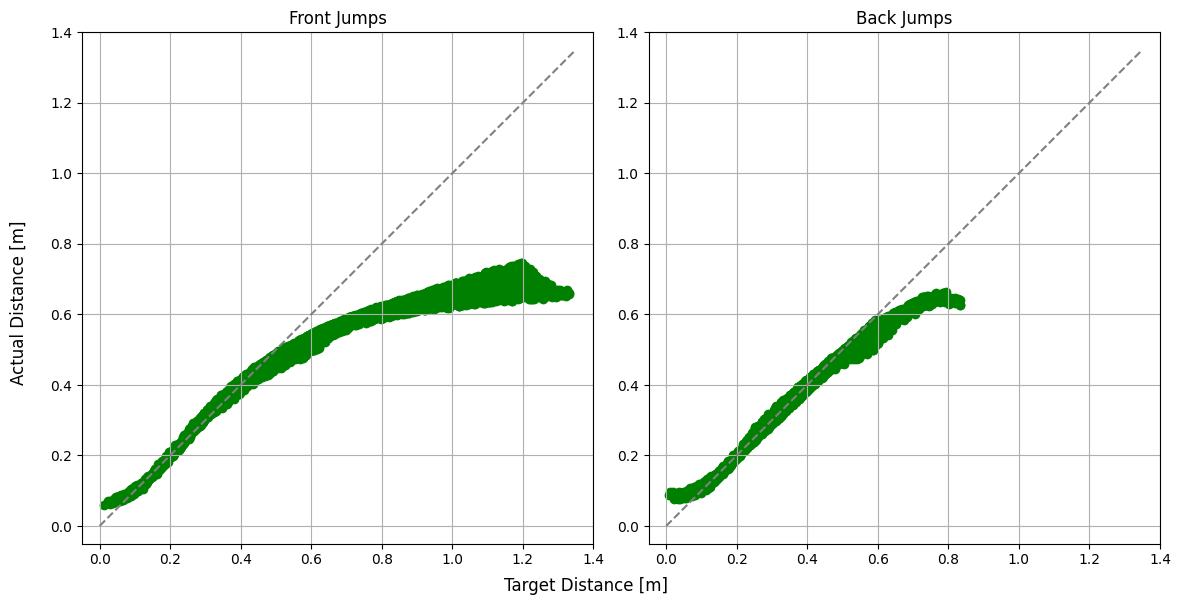

In [19]:
# Create side-by-side subplots with the specified sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot front jumps in the left subplot (green points, no color bar)
ax1.scatter(des_dist[front_jumps], actual_dist[front_jumps], color="green", marker='o')

# Plot back jumps in the right subplot (green points, no color bar)
ax2.scatter(des_dist[back_jumps], actual_dist[back_jumps], color="green", marker='o')

# Add dashed diagonal line to indicate ideal behavior (actual = desired)
ax1.plot([0, 1.35], [0, 1.35], '--', color='gray')
ax2.plot([0, 1.35], [0, 1.35], '--', color='gray')

# Set axis limits
ax1.set_xlim(-0.05, 1.4)
ax1.set_ylim(-0.05, 1.4)
ax2.set_xlim(-0.05, 1.4)
ax2.set_ylim(-0.05, 1.4)

# Set titles
ax1.set_title("Front Jumps")
ax2.set_title("Back Jumps")

# Make both subplots square
ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')

# Add grid (legend and colorbar removed)
ax1.grid(True)
ax2.grid(True)

# Use tight layout first to optimize the internal subplot layout
plt.tight_layout()

# Set shared axis labels after tight layout
fig.text(0.5, 0.02, 'Target Distance [m]', ha='center', fontsize=12)  # Adjust y-position for x-label
fig.text(0.02, 0.5, 'Actual Distance [m]', va='center', rotation='vertical', fontsize=12)  # Adjust x-position for y-label

# Adjust layout slightly with subplots_adjust to avoid overlapping with shared labels
plt.subplots_adjust(left=0.08, bottom=0.08)  # Adjust padding around the figure

# Display plot
plt.savefig(osp.join(data_path, "dist_res.pdf"), dpi=500, bbox_inches='tight')
plt.show()


In [20]:
np.linalg.norm([0.6,0.6])

0.848528137423857

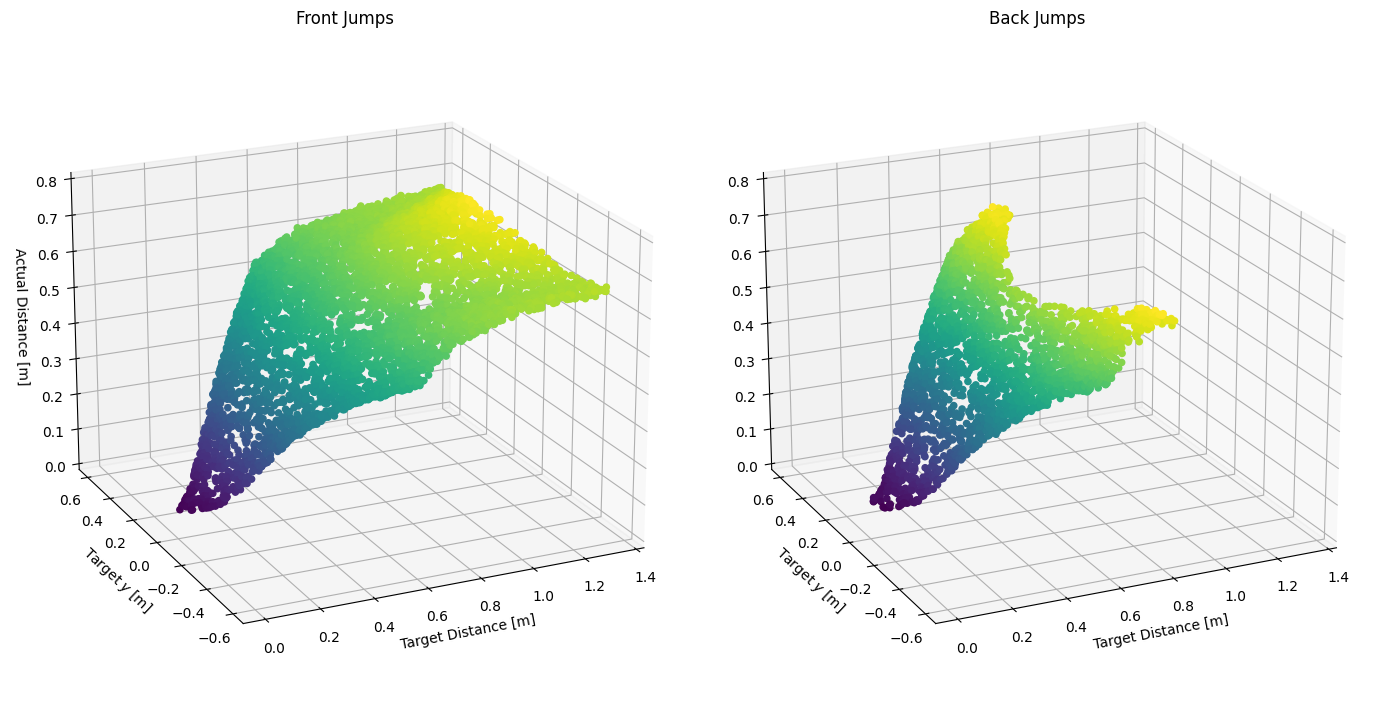

In [58]:
#  Create side-by-side 3D subplots
fig = plt.figure(figsize=(14, 7))

# Front jumps subplot
ax1 = fig.add_subplot(121, projection='3d')

# Plot front jumps and color them by pos_err using normalized scale
sc1 = ax1.scatter(des_dist[front_jumps], des_pos[front_jumps, 1], actual_dist[front_jumps], 
                  c=actual_dist[front_jumps], marker='o', alpha=1)

ax1.set_xlim(-0.05, 1.4 )
ax1.set_ylim(-0.65, 0.65)
ax1.set_zlim( 0 , 0.8)

# Set axis labels and title for front jumps
ax1.set_xlabel('Target Distance [m]')
ax1.set_ylabel('Target $y$ [m]')
ax1.set_zlabel('Actual Distance [m]')
ax1.set_title("Front Jumps")

# Rotate the plot by 90 degrees in yaw (Z-axis)
ax1.view_init(elev=20, azim=245)  # Adjust the elev (tilt) and azim (yaw)

# Back jumps subplot
ax2 = fig.add_subplot(122, projection='3d')

# Plot back jumps and color them by pos_err using normalized scale
sc2 = ax2.scatter(des_dist[back_jumps], des_pos[back_jumps, 1], actual_dist[back_jumps], 
                  c=actual_dist[back_jumps], marker='o', alpha=1)

ax2.set_xlim(-0.05, 1.4 )
ax2.set_ylim(-0.65, 0.65)
ax2.set_zlim( 0 , 0.8)

# Set axis labels and title for back jumps
ax2.set_xlabel('Target Distance [m]')
ax2.set_ylabel('Target $y$ [m]')
# ax2.set_zlabel('Actual Distance [m]')
ax2.set_title("Back Jumps")

# Rotate the plot by 90 degrees in yaw (Z-axis)
ax2.view_init(elev=20, azim=245)  # Adjust the elev (tilt) and azim (yaw)

# Add grid to both subplots
ax1.grid(True)
ax2.grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig(osp.join(data_path, "dist_res_3d.pdf"), dpi=500, bbox_inches='tight')
plt.show()

### Heihgt, only liner part

In [100]:
exp_path = osp.join(data_path, 'complete_linear_height')

In [101]:
data_pos = osp.join(exp_path, "pos_err.bin")
data_orient_err = osp.join(exp_path, "orient_err.bin")
data_fail = osp.join(exp_path, "failed.bin")

In [102]:
pos = joblib.load(data_pos)
orient_err = joblib.load(data_orient_err)
fail = joblib.load(data_fail)

In [103]:
des_pos = pos[0]
des_pos[:, 2] -= 0.5 #starting z

In [104]:
actual_pos = pos[1]
actual_pos[:, 2] -= 0.5 #starting z

In [105]:
pos_err = np.linalg.norm(des_pos - actual_pos, axis=1)

In [106]:
print("avg pos error: ", pos_err.mean())

avg pos error:  0.15638986


In [107]:
failed_idx = np.nonzero(fail)[0]
print("failed jumps: ", failed_idx.shape)

failed jumps:  (34,)


In [108]:
failed_jump_des = des_pos[failed_idx]

In [109]:
feasible_idx = pos_err <= 0.2

In [110]:
feasible_idx.shape

(8000,)

In [116]:
des_pos[:, 2], actual_pos[:, 2]

(array([ 0.24055213, -0.16960853,  0.33321494, ...,  0.09007126,
         0.24301964,  0.2326693 ], dtype=float32),
 array([ 0.15008807, -0.16622576,  0.20219964, ...,  0.11230874,
         0.2030487 ,  0.1528635 ], dtype=float32))

In [113]:
# plt.figure(figsize=(13, 6))

# plt.grid()

# # Enlarge marker size for desired positions with custom log scale for error values
# sc = plt.scatter(des_pos[:, 0][feasible_idx], des_pos[:, 1][feasible_idx], 
#                  np.full(des_pos[:, 1][feasible_idx].shape, 10),  # Enlarged marker size
#                  marker='o', c=actual_pos[:, 2][feasible_idx], zorder=10)  # Apply the custom colormap

# plt.xlim(-0.62, 1.22)
# plt.ylim(-0.62, 0.62)

# # Set x-axis ticks with equal spacing of 0.1
# plt.xticks(np.arange(-0.6, 1.3, 0.2))  # Generate ticks from -0.6 to 1.2 with a step of 0.1

# # Add colorbar with specified ticks and labels, adjust 'pad' to bring it closer to the plot
# cbar = plt.colorbar(sc, pad=0.01)  # Reduce the pad value to bring the colorbar closer

# # Add label to colorbar with label padding
# cbar.set_label("Height [m]", labelpad=15)  # Adjust label padding

# # Add grid, title, and labels
# plt.title("Unitree GO1")
# plt.xlabel("Target $x$ [m]")
# plt.ylabel("Target $y$ [m]")

# # Automatically adjust layout
# # plt.tight_layout()

# # Save and show plot
# plt.savefig(osp.join(data_path , "abs_err_feasible.pdf"), dpi=500, bbox_inches='tight')
# plt.show()

In [146]:
%matplotlib inline

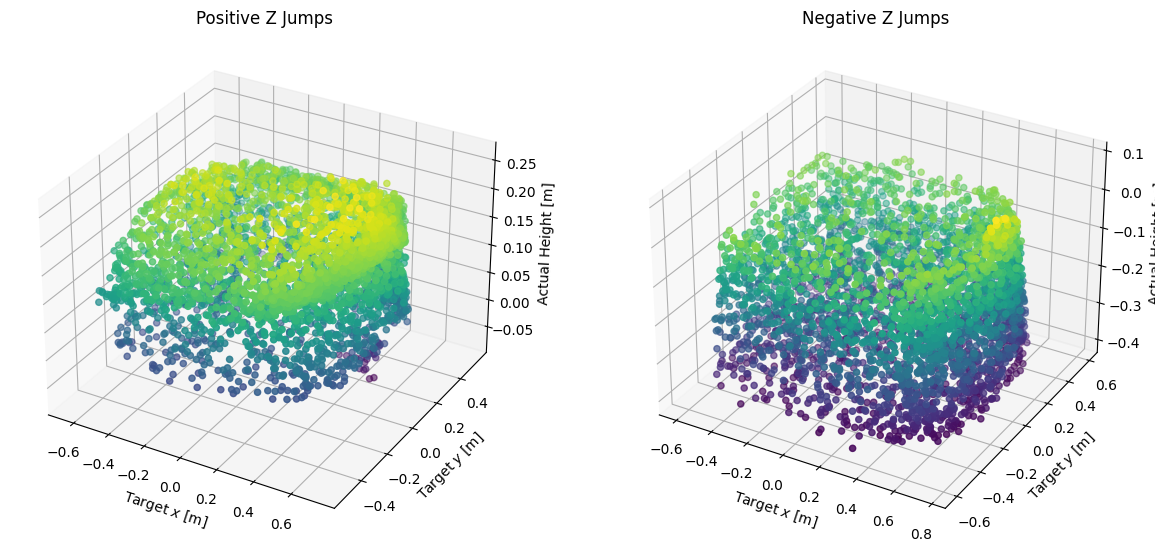

In [147]:
# Classify jumps based on the desired Z-value (positive or negative Z)
positive_z_idx = (des_pos[:, 2] > 0) & (fail == 0)  # Positive Z jumps excluding failed experiments
negative_z_idx = (des_pos[:, 2] < 0) & (fail == 0)  # Negative Z jumps excluding failed experiments


# Positive Z jumps
positive_z_des = des_pos[positive_z_idx]
positive_z_actual = actual_pos[positive_z_idx]

# Negative Z jumps
negative_z_des = des_pos[negative_z_idx]
negative_z_actual = actual_pos[negative_z_idx]

# Create side-by-side 3D subplots
fig = plt.figure(figsize=(14, 7))

# Positive Z jumps subplot
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(positive_z_actual[:, 0], positive_z_actual[:, 1], positive_z_actual[:, 2], 
                  c=positive_z_actual[:, 2], cmap='viridis', marker='o')
ax1.set_xlabel('Target $x$ [m]')
ax1.set_ylabel('Target $y$ [m]')
ax1.set_zlabel('Actual Height [m]')
ax1.set_title("Positive Z Jumps")
# ax1.set_xlim(-0.62, 1.22)
# ax1.set_ylim(-0.62, 0.62)
# ax1.set_zlim(-0.5, 0.8)

# Negative Z jumps subplot
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(negative_z_actual[:, 0], negative_z_actual[:, 1], negative_z_actual[:, 2], 
                  c=negative_z_actual[:, 2], cmap='viridis', marker='o')
ax2.set_xlabel('Target $x$ [m]')
ax2.set_ylabel('Target $y$ [m]')
ax2.set_zlabel('Actual Height [m]')
ax2.set_title("Negative Z Jumps")
# ax2.set_xlim(-0.62, 1.22)
# ax2.set_ylim(-0.62, 0.62)
# ax2.set_zlim(-0.5, 0.8)

# Add a single colorbar on the right for both subplots
# cbar = fig.colorbar(sc2, ax=[ax1, ax2], shrink=0.6, pad=0.1)
# cbar.set_label("Height [m]", labelpad=15)

# Adjust layout to fit labels and colorbar
plt.subplots_adjust(left=0.05, right=0.85, top=0.9)

# Save the plot and display it
plt.savefig(osp.join(data_path, "3d_height_jumps_pos_neg_z.pdf"), dpi=500, bbox_inches='tight')
plt.show()

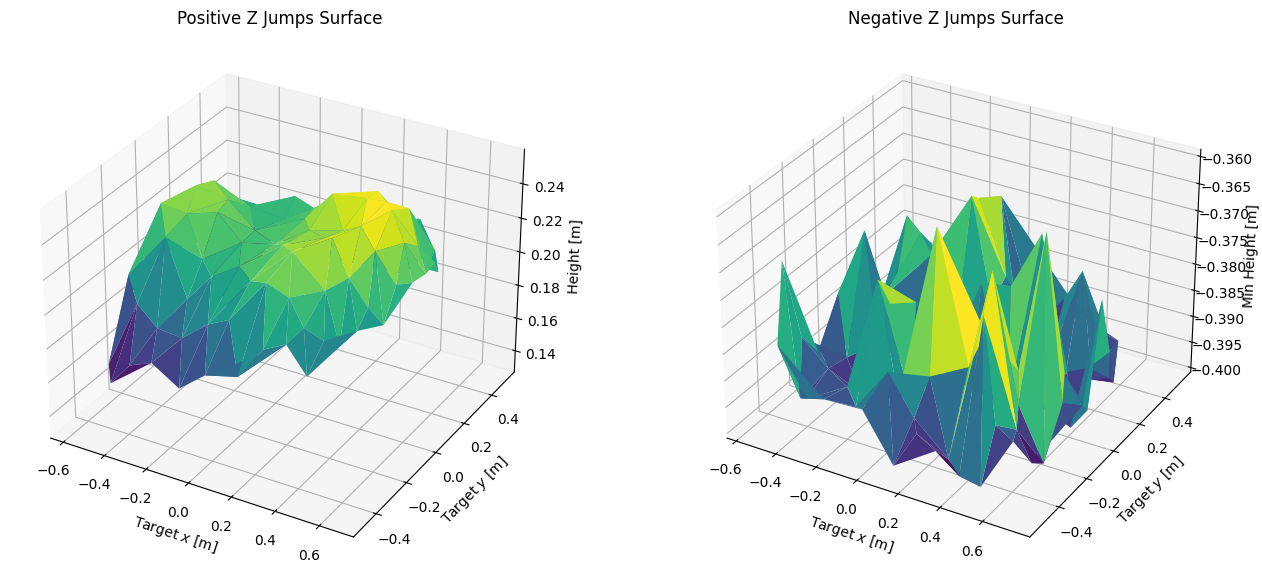

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
import os.path as osp

def create_clustered_height_map_surface(x, y, z, ax, title, n_clusters=200, use_max=True):
    """Create a 3D surface plot using KMeans clustering on x and y, and taking the max or min z for each cluster."""
    # Stack x and y coordinates for clustering
    xy = np.column_stack((x, y))

    # Perform KMeans clustering on x and y coordinates
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(xy)

    # Get the cluster centers and cluster labels
    cluster_centers = kmeans.cluster_centers_
    labels = kmeans.labels_

    # Create an array to store the max/min height for each cluster
    cluster_heights = np.full(n_clusters, np.nan)

    # Loop over each cluster and calculate the maximum/minimum z value for points in that cluster
    for cluster in range(n_clusters):
        in_cluster = (labels == cluster)
        if np.any(in_cluster):
            if use_max:
                cluster_heights[cluster] = np.max(z[in_cluster])
            else:
                cluster_heights[cluster] = np.min(z[in_cluster])

    # Plot the 3D surface using the cluster centers and max/min heights
    ax.plot_trisurf(cluster_centers[:, 0], cluster_centers[:, 1], cluster_heights, cmap='viridis')

    # Set labels and title
    ax.set_xlabel('Target $x$ [m]')
    ax.set_ylabel('Target $y$ [m]')
    ax.set_zlabel('Height [m]' if use_max else 'Min Height [m]')
    ax.set_title(title)

# Classify jumps based on the desired Z-value and remove failed experiments
positive_z_idx = (des_pos[:, 2] > 0) & (fail == 0)  # Positive Z jumps excluding failed experiments
negative_z_idx = (des_pos[:, 2] < 0) & (fail == 0)  # Negative Z jumps excluding failed experiments

# Positive Z jumps
positive_z_actual = actual_pos[positive_z_idx]

# Negative Z jumps
negative_z_actual = actual_pos[negative_z_idx]

# Create a figure for the 3D surface plot
fig = plt.figure(figsize=(16, 7))

# Positive Z subplot (Maximum Z)
ax1 = fig.add_subplot(121, projection='3d')
create_clustered_height_map_surface(positive_z_actual[:, 0], positive_z_actual[:, 1], positive_z_actual[:, 2], ax1, "Positive Z Jumps Surface", 100, use_max=True)

# Negative Z subplot (Minimum Z)
ax2 = fig.add_subplot(122, projection='3d')
create_clustered_height_map_surface(negative_z_actual[:, 0], negative_z_actual[:, 1], negative_z_actual[:, 2], ax2, "Negative Z Jumps Surface", 100, use_max=False)

# Save the plot and display it
plt.savefig(osp.join(data_path, "kmeans_clustered_3d_surface_pos_neg_z_no_failures.pdf"), dpi=500, bbox_inches='tight')
plt.show()


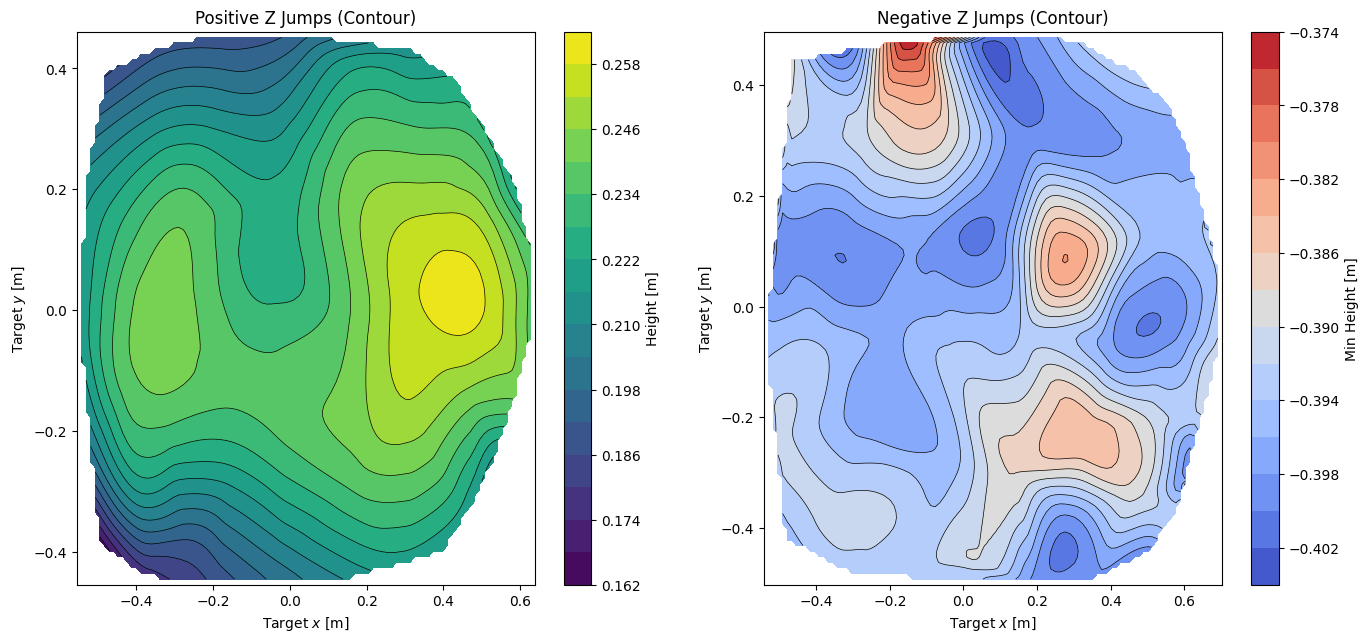

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.interpolate import griddata
import os.path as osp

def create_clustered_height_map_contour(x, y, z, ax, title, n_clusters=100, use_max=True, cmap='viridis'):
    """Create a 2D contour plot using KMeans clustering on x and y, and taking max or min z for each cluster."""
    # Stack x and y coordinates for clustering
    xy = np.column_stack((x, y))

    # Perform KMeans clustering on x and y coordinates
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(xy)

    # Get the cluster centers and cluster labels
    cluster_centers = kmeans.cluster_centers_
    labels = kmeans.labels_

    # Create an array to store the max/min height for each cluster
    cluster_heights = np.full(n_clusters, np.nan)

    # Loop over each cluster and calculate the maximum/minimum z value for points in that cluster
    for cluster in range(n_clusters):
        in_cluster = (labels == cluster)
        if np.any(in_cluster):
            if use_max:
                cluster_heights[cluster] = np.max(z[in_cluster])
            else:
                cluster_heights[cluster] = np.min(z[in_cluster])

    # Create a grid for X and Y to interpolate the Z values (cluster heights)
    grid_x, grid_y = np.mgrid[min(cluster_centers[:, 0]):max(cluster_centers[:, 0]):100j,
                              min(cluster_centers[:, 1]):max(cluster_centers[:, 1]):100j]

    # Interpolate Z values onto the grid
    grid_z = griddata(cluster_centers, cluster_heights, (grid_x, grid_y), method='cubic')

    # Plot the filled contour map
    contf = ax.contourf(grid_x, grid_y, grid_z, levels=15, cmap=cmap)

    # Add contour lines with solid linestyle for consistency
    cont = ax.contour(grid_x, grid_y, grid_z, levels=15, colors='black', linewidths=0.5, linestyles='solid')

    # Add colorbar for filled contours
    cbar = plt.colorbar(contf, ax=ax)
    cbar.set_label("Positive Height [m]" if use_max else "Negative Height [m]")

    # Set labels and title
    ax.set_xlabel('Target $x$ [m]')
    ax.set_ylabel('Target $y$ [m]')
    ax.set_title(title)

# Classify jumps based on the desired Z-value and remove failed experiments
positive_z_idx = (des_pos[:, 2] > 0) & (fail == 0)  # Positive Z jumps excluding failed experiments
negative_z_idx = (des_pos[:, 2] < 0) & (fail == 0)  # Negative Z jumps excluding failed experiments

# Positive Z jumps
positive_z_actual = actual_pos[positive_z_idx]

# Negative Z jumps
negative_z_actual = actual_pos[negative_z_idx]

# Create a figure for the 2D contour plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Generate 2D contour plot for positive Z jumps using KMeans (max Z, 'viridis' colormap)
create_clustered_height_map_contour(positive_z_actual[:, 0], positive_z_actual[:, 1], positive_z_actual[:, 2], 
                                    ax1, "Positive Z Jumps (Contour)", 50, use_max=True, cmap='viridis')

# Generate 2D contour plot for negative Z jumps using KMeans (min Z, 'coolwarm' colormap)
create_clustered_height_map_contour(negative_z_actual[:, 0], negative_z_actual[:, 1], negative_z_actual[:, 2], 
                                    ax2, "Negative Z Jumps (Contour)", 50, use_max=False, cmap='coolwarm')

# Adjust layout to fit labels and colorbars
plt.subplots_adjust(left=0.05, right=0.95, top=0.9)

# Save the plot and display it
plt.savefig(osp.join(data_path, "kmeans_clustered_2d_contour_pos_neg_z_solid_lines.pdf"), dpi=500, bbox_inches='tight')
plt.show()
